# K-Medoids (PAM) sur le Dataset Digits

**Algorithme :** K-Medoids (PAM)  
**Dataset :** Digits (sklearn) - reconnaissance de chiffres manuscrits 8x8  
**Split :** 70 % train / 15 % validation / 15 % test  
**Objectif :** Regrouper les chiffres en 10 clusters sans utiliser les labels, puis evaluer la coherence avec la verite terrain

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score, confusion_matrix
)
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

  DIGITS - APERCU GENERAL
  Samples      : 1797
  Features     : 64 (pixels 8x8)
  Classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Valeurs NaN  : 0

  DISTRIBUTION DES CLASSES
  Chiffre 0 : 178 samples
  Chiffre 1 : 182 samples
  Chiffre 2 : 177 samples
  Chiffre 3 : 183 samples
  Chiffre 4 : 181 samples
  Chiffre 5 : 182 samples
  Chiffre 6 : 181 samples
  Chiffre 7 : 179 samples
  Chiffre 8 : 174 samples
  Chiffre 9 : 180 samples

  STATISTIQUES DESCRIPTIVES (pixels)
            0        1        2        3        4        5        6        7
count  1797.0  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00
mean      0.0     0.30     5.20    11.84    11.85     5.78     1.36     0.13
std       0.0     0.91     4.75     4.25     4.29     5.67     3.33     1.04
min       0.0     0.00     0.00     0.00     0.00     0.00     0.00     0.00
25%       0.0     0.00     1.00    10.00    10.00     0.00     0.00     0.00
50%       0.0     0.00     4.00    13.00    13.00     4.00     0

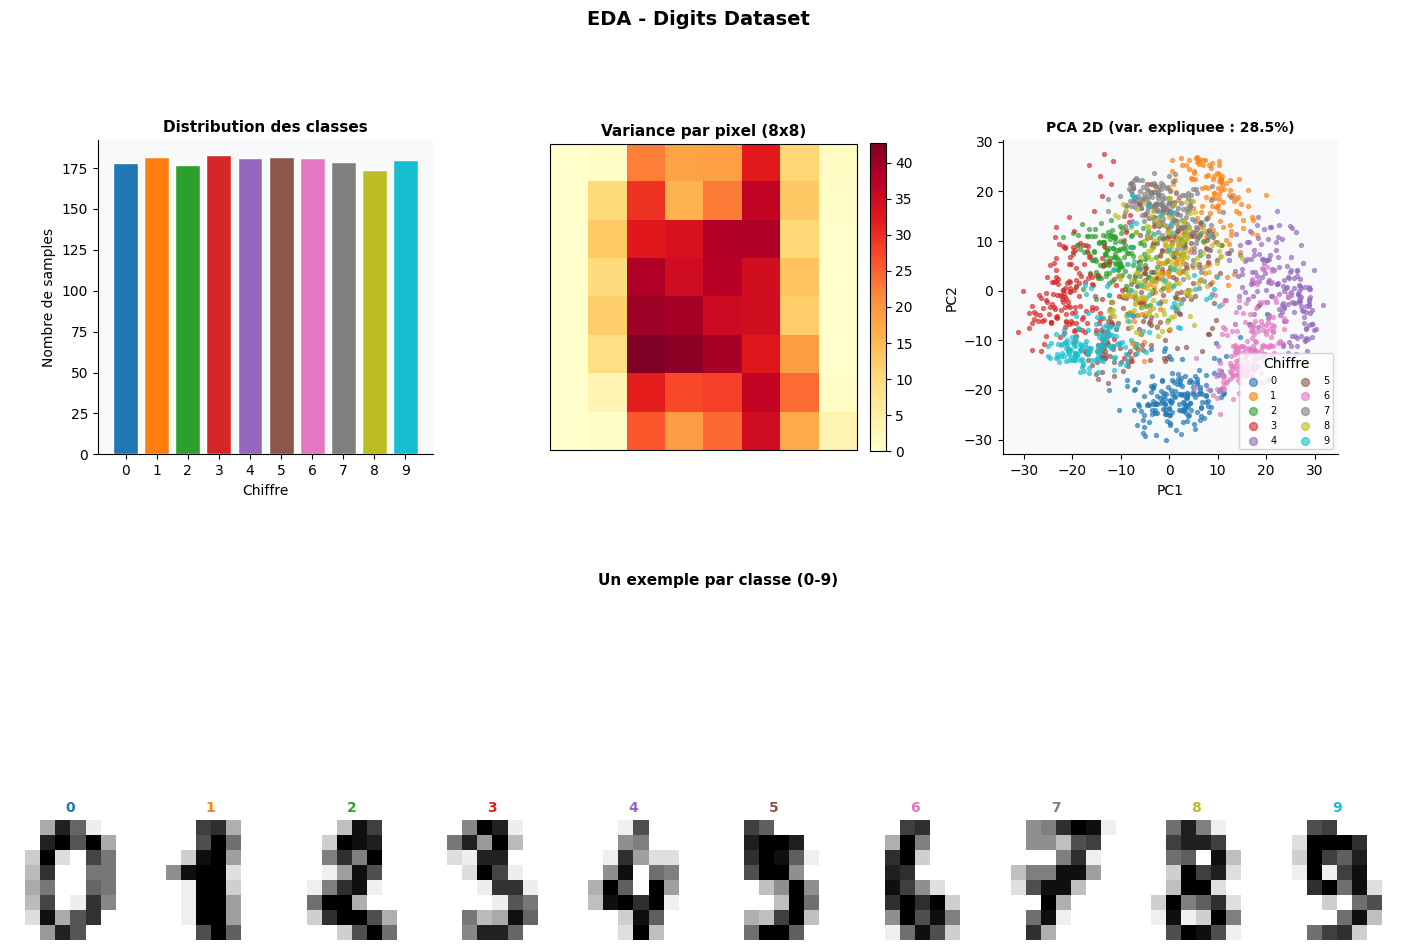

In [2]:
# -- 1. Chargement -------------------------------------------------------------
digits = load_digits()
X_raw = digits.data
y_raw = digits.target

print('=' * 55)
print('  DIGITS - APERCU GENERAL')
print('=' * 55)
print(f'  Samples      : {X_raw.shape[0]}')
print(f'  Features     : {X_raw.shape[1]} (pixels 8x8)')
print(f'  Classes      : {np.unique(y_raw).tolist()}')
print(f'  Valeurs NaN  : {np.isnan(X_raw).sum()}')

print('\n' + '=' * 55)
print('  DISTRIBUTION DES CLASSES')
print('=' * 55)
unique, counts = np.unique(y_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Chiffre {u} : {c} samples')

print('\n' + '=' * 55)
print('  STATISTIQUES DESCRIPTIVES (pixels)')
print('=' * 55)
df = pd.DataFrame(X_raw)
print(df.describe().round(2).iloc[:, :8].to_string())

print('\n' + '=' * 55)
print('  VARIANCE MOYENNE PAR PIXEL')
print('=' * 55)
pixel_var = X_raw.var(axis=0).reshape(8, 8)
print(f'  Variance min  : {pixel_var.min():.3f}  (pixels de bord)')
print(f'  Variance max  : {pixel_var.max():.3f}  (centre du chiffre)')
print(f'  Variance moy  : {pixel_var.mean():.3f}')

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_10 = plt.cm.tab10(np.linspace(0, 1, 10))

ax0 = fig.add_subplot(gs[0, 0])
ax0.bar(unique, counts, color=colors_10, edgecolor='white')
ax0.set_title('Distribution des classes', fontsize=11, fontweight='bold')
ax0.set_xlabel('Chiffre')
ax0.set_ylabel('Nombre de samples')
ax0.set_xticks(unique)
ax0.set_facecolor('#f8f9fa')
ax0.spines[['top', 'right']].set_visible(False)

ax1 = fig.add_subplot(gs[0, 1])
im = ax1.imshow(pixel_var, cmap='YlOrRd')
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_title('Variance par pixel (8x8)', fontsize=11, fontweight='bold')
ax1.set_xticks([])
ax1.set_yticks([])

ax2 = fig.add_subplot(gs[0, 2])
pca_eda = PCA(n_components=2, random_state=42)
X_pca2 = pca_eda.fit_transform(X_raw)
for i in range(10):
    mask = y_raw == i
    ax2.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                color=colors_10[i], label=str(i), s=8, alpha=0.6)
ax2.set_title(f'PCA 2D (var. expliquee : {pca_eda.explained_variance_ratio_.sum() * 100:.1f}%)',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(title='Chiffre', fontsize=7, ncol=2,
           loc='lower right', markerscale=2)
ax2.set_facecolor('#f8f9fa')
ax2.spines[['top', 'right']].set_visible(False)

ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')
ax3.set_title('Un exemple par classe (0-9)', fontsize=11,
              fontweight='bold', pad=8)
for i in range(10):
    idx = np.where(y_raw == i)[0][0]
    ax_i = fig.add_axes([0.07 + i * 0.088, 0.07, 0.075, 0.14])
    ax_i.imshow(X_raw[idx].reshape(8, 8), cmap='gray_r')
    ax_i.set_title(str(i), fontsize=10, fontweight='bold',
                   color=colors_10[i])
    ax_i.axis('off')

fig.suptitle('EDA - Digits Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.show();

In [3]:
# -- Preprocessing ------------------------------------------------------------
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=42, stratify=y_raw
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')


class PAMKMedoids:
    """Implementation compacte de K-Medoids avec phase SWAP (PAM)."""
    def __init__(self, n_clusters=10, max_iter=20, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X)
        n_samples = X.shape[0]

        if self.n_clusters >= n_samples:
            raise ValueError('n_clusters must be smaller than number of samples')

        D = cdist(X, X, metric='euclidean')
        medoids = rng.choice(n_samples, size=self.n_clusters, replace=False)

        for _ in range(self.max_iter):
            dist_to_medoids = D[:, medoids]
            nearest_pos = np.argmin(dist_to_medoids, axis=1)
            best_dist = dist_to_medoids[np.arange(n_samples), nearest_pos]

            temp = dist_to_medoids.copy()
            temp[np.arange(n_samples), nearest_pos] = np.inf
            second_best = np.min(temp, axis=1)

            current_cost = best_dist.sum()
            best_swap = None
            best_swap_cost = current_cost

            non_medoids = np.setdiff1d(np.arange(n_samples), medoids, assume_unique=False)

            for m_pos, m_idx in enumerate(medoids):
                mask_assigned_to_m = nearest_pos == m_pos
                for h in non_medoids:
                    candidate_dist = D[:, h]
                    swapped_best = np.where(mask_assigned_to_m,
                                            np.minimum(candidate_dist, second_best),
                                            np.minimum(candidate_dist, best_dist))
                    swap_cost = swapped_best.sum()
                    if swap_cost < best_swap_cost - 1e-9:
                        best_swap_cost = swap_cost
                        best_swap = (m_pos, h)

            if best_swap is None:
                break

            medoids[best_swap[0]] = best_swap[1]

        self.medoid_indices_ = np.sort(medoids)
        self.cluster_centers_ = X[self.medoid_indices_]
        self.labels_ = self.predict(X)
        return self

    def predict(self, X):
        X = np.asarray(X)
        d = cdist(X, self.cluster_centers_, metric='euclidean')
        return np.argmin(d, axis=1)




Train : 1257 samples
Val   : 270 samples
Test  : 270 samples


In [5]:
# -- Fonctions utilitaires  ---------------------------------------------------
def align_labels(y_true, y_pred, n_clusters=10):
    """Aligner les clusters aux labels reels via l'algorithme hongrois."""
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_clusters)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping.get(p, p) for p in y_pred])

In [6]:
# -- Hyperparameter Tuning ---------------------------------------------------
# Tester differentes combinaisons de n_clusters et max_iter sur la VALIDATION set
param_grid = {
    'n_clusters': [8, 9, 10, 11, 12],
    'max_iter': [10, 15, 20, 25]
}

results_tuning = []

print('=' * 70)
print('  HYPERPARAMETER TUNING — K-Medoids (PAM)')
print('=' * 70)
print(f'  Testing {len(param_grid["n_clusters"]) * len(param_grid["max_iter"])} configurations...\n')

for n_clusters in param_grid['n_clusters']:
    for max_iter in param_grid['max_iter']:
        # Entraîner sur TRAIN
        model_temp = PAMKMedoids(n_clusters=n_clusters, max_iter=max_iter, random_state=42)
        model_temp.fit(X_train)
        
        # Evaluer sur VAL (pour la selection)
        labels_val_temp = model_temp.predict(X_val)
        
        # Metriques de validation
        ari_val = adjusted_rand_score(y_val, labels_val_temp)
        nmi_val = normalized_mutual_info_score(y_val, labels_val_temp)
        sil_val = silhouette_score(X_val, labels_val_temp, sample_size=min(500, X_val.shape[0]), random_state=42)
        labels_aligned_val_temp = align_labels(y_val, labels_val_temp, n_clusters=n_clusters)
        acc_val = (labels_aligned_val_temp == y_val).mean()
        
        # Score composite pour selection (moyenne normalisee des metriques)
        composite_score = (acc_val + ari_val + nmi_val + (sil_val + 1) / 2) / 4
        
        results_tuning.append({
            'n_clusters': n_clusters,
            'max_iter': max_iter,
            'acc_val': acc_val,
            'ari_val': ari_val,
            'nmi_val': nmi_val,
            'sil_val': sil_val,
            'composite_score': composite_score
        })
        
        print(f'  n_clusters={n_clusters:2d}, max_iter={max_iter:2d} | '
              f'Acc: {acc_val:.4f}, ARI: {ari_val:.4f}, NMI: {nmi_val:.4f}, '
              f'Sil: {sil_val:.4f}, Score: {composite_score:.4f}')

# Trouver la meilleure configuration
best_idx = np.argmax([r['composite_score'] for r in results_tuning])
best_config = results_tuning[best_idx]

print('\n' + '=' * 70)
print('  MEILLEURE CONFIGURATION')
print('=' * 70)
print(f'  n_clusters : {int(best_config["n_clusters"])}')
print(f'  max_iter   : {int(best_config["max_iter"])}')
print(f'  Val Accuracy : {best_config["acc_val"]:.4f}')
print(f'  Val ARI      : {best_config["ari_val"]:.4f}')
print(f'  Val NMI      : {best_config["nmi_val"]:.4f}')
print(f'  Val Silhouette : {best_config["sil_val"]:.4f}')
print(f'  Composite Score : {best_config["composite_score"]:.4f}\n')

# -- Reentrainer avec la meilleure config sur TRAIN+VAL pour TEST ---------------
best_n_clusters = int(best_config['n_clusters'])
best_max_iter = int(best_config['max_iter'])

print('=' * 70)
print('  ENTRAÎNEMENT FINAL (Train + Val pooled)')
print('=' * 70)

# Pool train + val pour entraîner le modèle final
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

model = PAMKMedoids(n_clusters=best_n_clusters, max_iter=best_max_iter, random_state=42)
model.fit(X_train_val)

print(f'  Model trained on {X_train_val.shape[0]} samples (Train + Val pooled)')

  HYPERPARAMETER TUNING — K-Medoids (PAM)
  Testing 20 configurations...

  n_clusters= 8, max_iter=10 | Acc: 0.6556, ARI: 0.5161, NMI: 0.6428, Sil: 0.0798, Score: 0.5886
  n_clusters= 8, max_iter=15 | Acc: 0.6370, ARI: 0.5109, NMI: 0.6536, Sil: 0.0851, Score: 0.5860
  n_clusters= 8, max_iter=20 | Acc: 0.6370, ARI: 0.5109, NMI: 0.6536, Sil: 0.0851, Score: 0.5860
  n_clusters= 8, max_iter=25 | Acc: 0.6370, ARI: 0.5109, NMI: 0.6536, Sil: 0.0851, Score: 0.5860
  n_clusters= 9, max_iter=10 | Acc: 0.6481, ARI: 0.4697, NMI: 0.6168, Sil: 0.0975, Score: 0.5709
  n_clusters= 9, max_iter=15 | Acc: 0.6963, ARI: 0.5319, NMI: 0.6717, Sil: 0.0996, Score: 0.6124
  n_clusters= 9, max_iter=20 | Acc: 0.6963, ARI: 0.5319, NMI: 0.6717, Sil: 0.0996, Score: 0.6124
  n_clusters= 9, max_iter=25 | Acc: 0.6963, ARI: 0.5319, NMI: 0.6717, Sil: 0.0996, Score: 0.6124
  n_clusters=10, max_iter=10 | Acc: 0.7148, ARI: 0.5237, NMI: 0.6517, Sil: 0.0722, Score: 0.6066
  n_clusters=10, max_iter=15 | Acc: 0.7185, ARI: 0.52

In [7]:
# -- Alignement cluster -> label (Hungarian algorithm) -----------------------
def align_labels(y_true, y_pred, n_clusters=10):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_clusters)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping.get(p, p) for p in y_pred])


def evaluate_clustering(model, X, y, split_name, n_clusters):
    labels_pred = model.predict(X)
    labels_aligned = align_labels(y, labels_pred, n_clusters=n_clusters)

    ari = adjusted_rand_score(y, labels_pred)
    nmi = normalized_mutual_info_score(y, labels_pred)
    sil = silhouette_score(X, labels_pred, sample_size=min(500, X.shape[0]), random_state=42)
    acc = (labels_aligned == y).mean()

    print('\n' + '=' * 52)
    print(f'  {split_name}')
    print('=' * 52)
    print(f'  Accuracy (apres alignement) : {acc:.4f}')
    print(f'  Adjusted Rand Index (ARI)   : {ari:.4f}')
    print(f'  Normalized Mutual Info (NMI): {nmi:.4f}')
    print(f'  Silhouette Score            : {sil:.4f}')
    return labels_pred, labels_aligned



In [8]:

# Evaluer sur TEST avec le meilleur modele
labels_test, aligned_test = evaluate_clustering(model, X_test, y_test, 'TEST SET', best_n_clusters)


  TEST SET
  Accuracy (apres alignement) : 0.7741
  Adjusted Rand Index (ARI)   : 0.6702
  Normalized Mutual Info (NMI): 0.7709
  Silhouette Score            : 0.1451


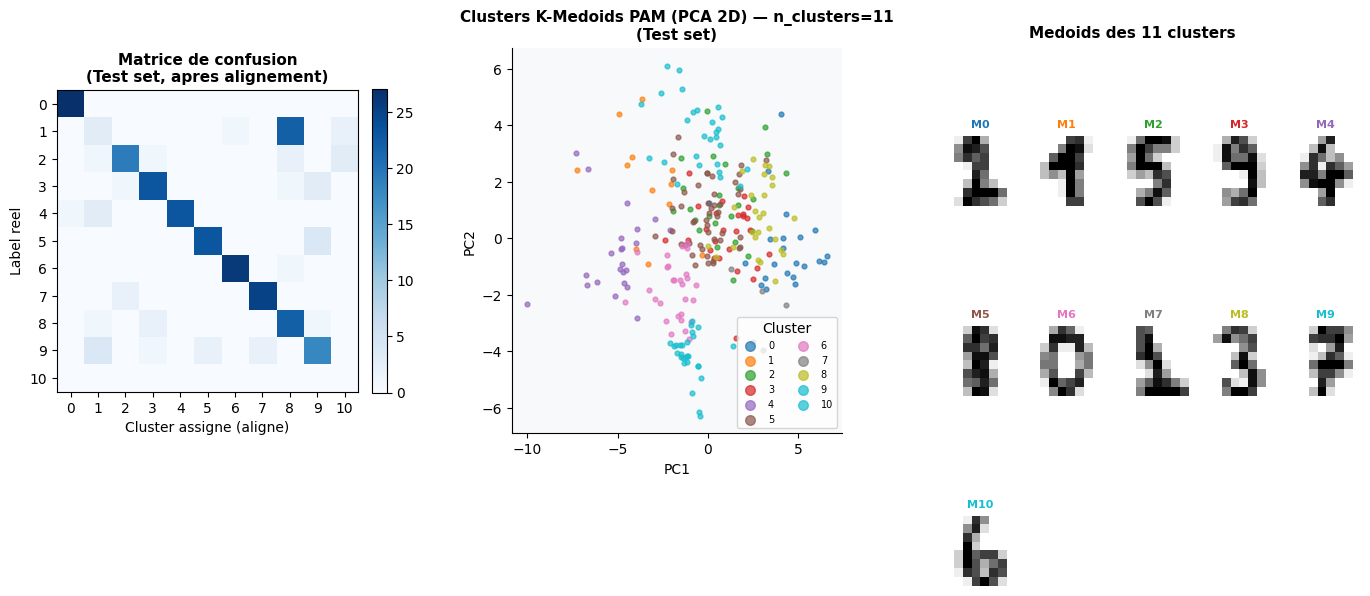

In [9]:
# -- Panel de visualisation ---------------------------------------------------
fig = plt.figure(figsize=(16, 5))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
cm_test = confusion_matrix(y_test, aligned_test, labels=list(range(best_n_clusters)))
im = ax1.imshow(cm_test, cmap='Blues')
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_xticks(range(best_n_clusters))
ax1.set_yticks(range(best_n_clusters))
ax1.set_xlabel('Cluster assigne (aligne)')
ax1.set_ylabel('Label reel')
ax1.set_title('Matrice de confusion\n(Test set, apres alignement)',
              fontsize=11, fontweight='bold')

pca_viz = PCA(n_components=2, random_state=42)
X_all = np.vstack([X_train, X_val, X_test])
pca_viz.fit(X_all)
X_test_2d = pca_viz.transform(X_test)

ax2 = fig.add_subplot(gs[0, 1])
colors_k = plt.cm.tab10(np.linspace(0, 1, best_n_clusters))
for i in range(best_n_clusters):
    mask = labels_test == i
    ax2.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                color=colors_k[i], s=12, alpha=0.7, label=str(i))
ax2.set_title(f'Clusters K-Medoids PAM (PCA 2D) — n_clusters={best_n_clusters}\n(Test set)', 
              fontsize=11, fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(title='Cluster', fontsize=7, ncol=2,
           loc='lower right', markerscale=2)
ax2.set_facecolor('#f8f9fa')
ax2.spines[['top', 'right']].set_visible(False)

ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
ax3.set_title(f'Medoids des {best_n_clusters} clusters', fontsize=11,
              fontweight='bold', pad=8)

# Combine X_train_raw and X_val_raw for reconstruction
X_train_val_raw = np.vstack([X_train_raw, X_val_raw])

# Get medoid indices and display them
medoid_indices = model.medoid_indices_
for i, midx in enumerate(medoid_indices):
    n_cols = min(5, best_n_clusters)
    n_rows = (best_n_clusters + n_cols - 1) // n_cols
    ax_m = fig.add_axes([0.68 + (i % n_cols) * 0.054,
                         0.50 - (i // n_cols) * 0.38,
                         0.044, 0.27])
    ax_m.imshow(X_train_val_raw[midx].reshape(8, 8), cmap='gray_r')
    ax_m.set_title(f'M{i}', fontsize=8, color=colors_k[i % len(colors_k)], fontweight='bold')
    ax_m.axis('off')

plt.show();